In [6]:
import sys
import warnings

sys.path.append("/kaggle/input/myscripts")
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from seq_models import SeqDataset, collate_fn, LSTMClassifier, TransformerClassifier, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Heart](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

In [3]:
import kagglehub

path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction") + "/heart.csv"

df = pd.read_csv(path)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]
le = LabelEncoder()
y = le.fit_transform(y)
labels = y.tolist()

In [7]:
categorical_features = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
scaler = StandardScaler()
X_numerical = scaler.fit_transform(X[numerical_features])

X_categorical = []
for col in categorical_features:
    le = LabelEncoder()
    encoded = le.fit_transform(X[col])
    X_categorical.append(encoded)

X_combined = np.column_stack([X_numerical] + X_categorical)

X_seqs = [row.reshape(len(row), 1) for row in X_combined]
train_data, test_data, train_labels, test_labels = train_test_split(X_seqs, labels, test_size=0.2, random_state=0, stratify=y, shuffle=True)
test_data, valid_data, test_labels, valid_labels = train_test_split(test_data, test_labels, test_size=0.5, random_state=0, stratify=test_labels, shuffle=True)

In [8]:
train_dataset = SeqDataset(train_data, train_labels)
test_dataset  = SeqDataset(test_data, test_labels)
valid_dataset = SeqDataset(valid_data, valid_labels)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


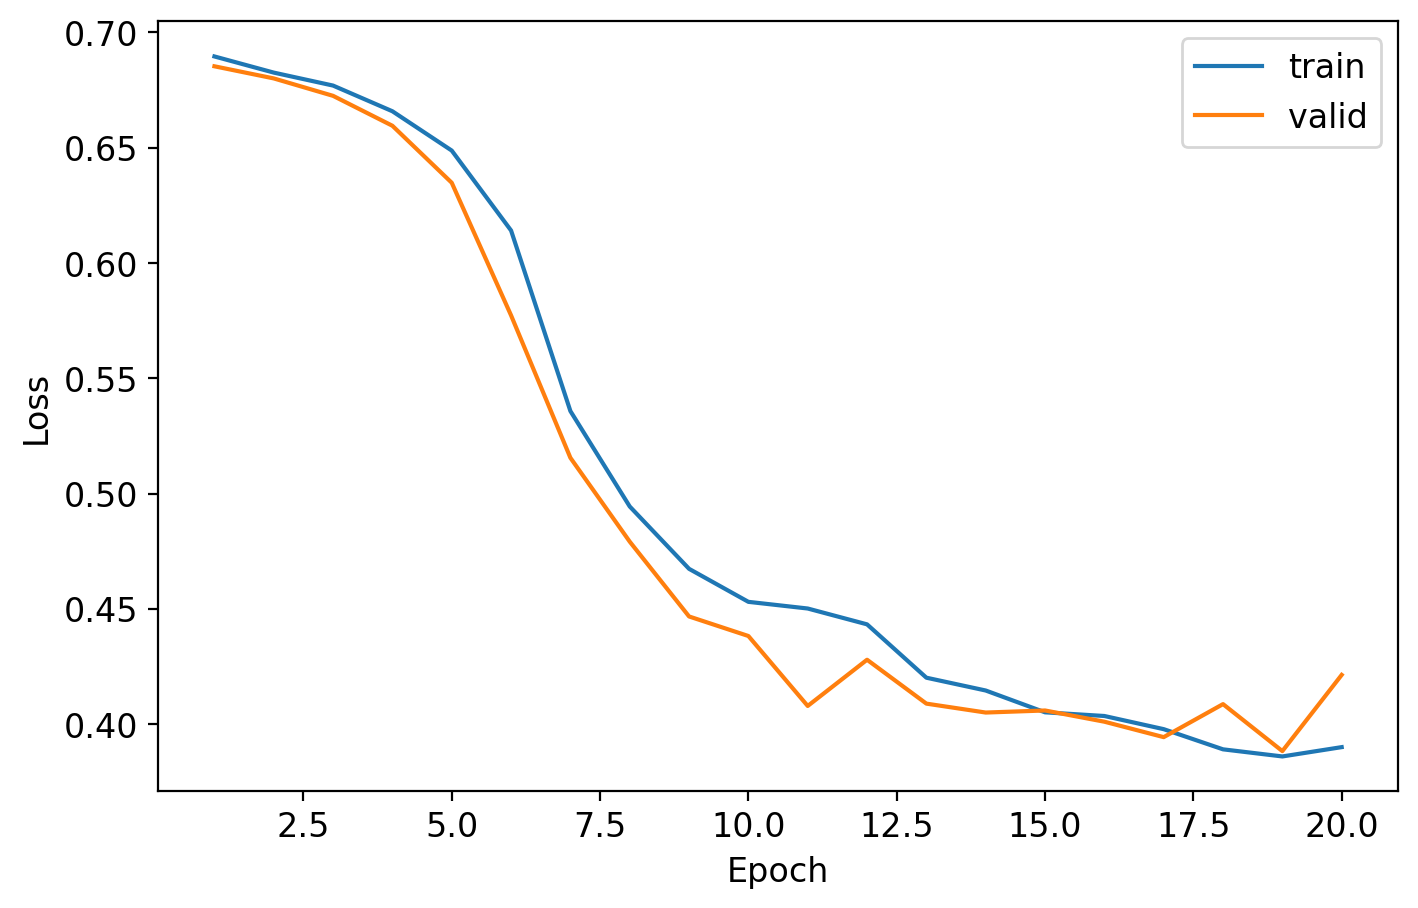

Epoch 20: train loss = 0.3900; valid loss = 0.4213


In [10]:
model_lstm = LSTMClassifier().to(device)
optimizer = optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(model_lstm, optimizer, 20, train_loader, valid_loader, criterion, device, scheduler=None)

In [12]:
y_true, y_prob, y_pred = evaluate(model_lstm, test_loader, device)
metrics_lstm = bootstrap_metrics(y_true, y_pred, y_prob)

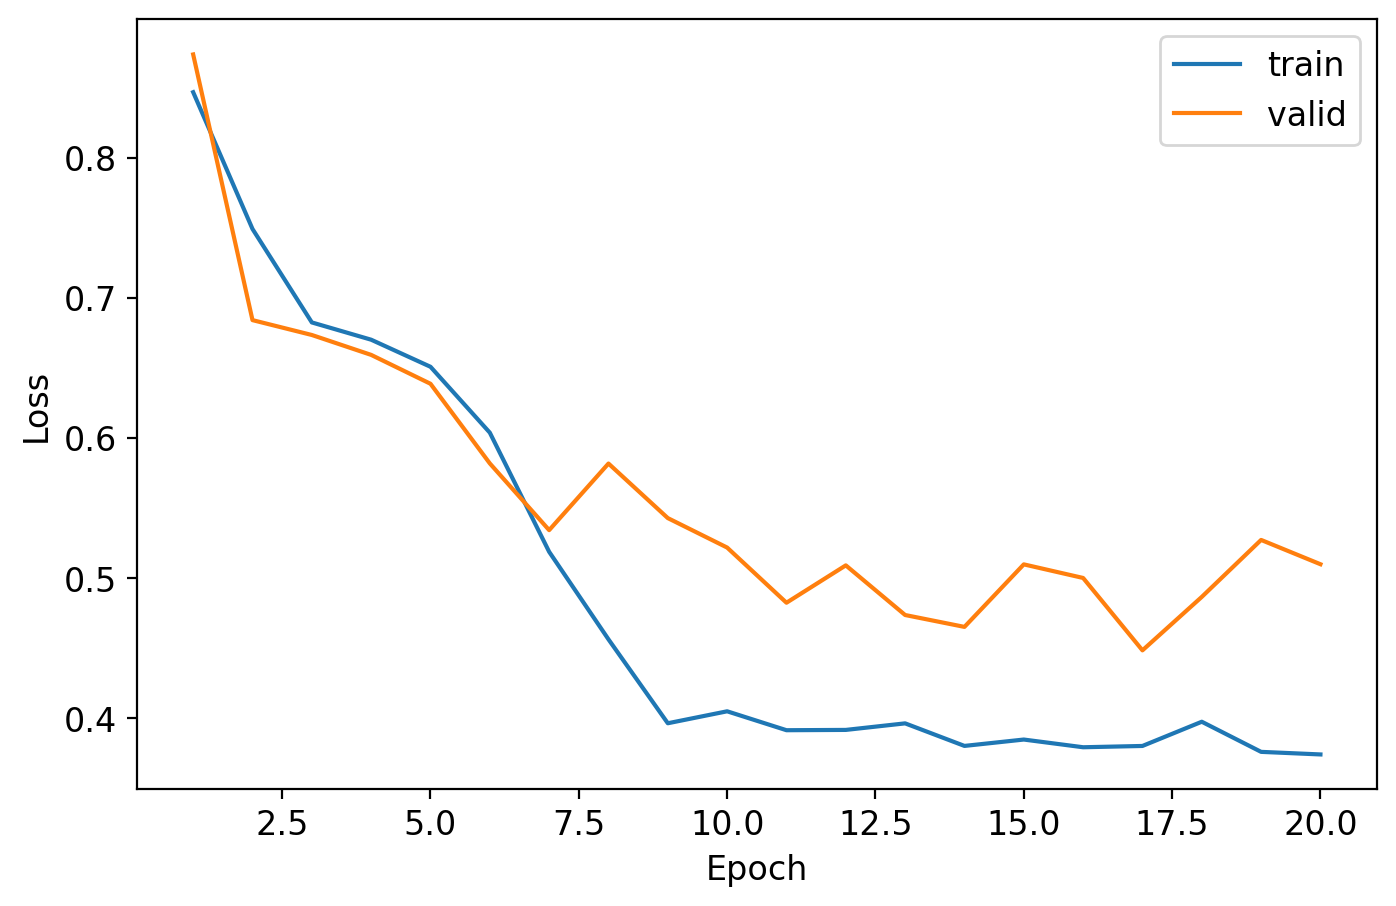

Epoch 20: train loss = 0.3741; valid loss = 0.5098


In [19]:
model_enc = TransformerClassifier(maxlen=len(train_data[0])).to(device)
optimizer = optim.Adam(model_enc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

train(model_enc, optimizer, 20, train_loader, valid_loader, criterion, device, scheduler=None)

In [20]:
y_true, y_prob, y_pred = evaluate(model_enc, test_loader, device)
metrics_enc = bootstrap_metrics(y_true, y_pred, y_prob)

In [21]:
res = pd.DataFrame([{"model": "LSTM"} | metrics_lstm, {"model": "Transformer"} | metrics_enc])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,LSTM,0.9185±0.0286,0.8275±0.0426,0.8253±0.0397,0.9065±0.0438,0.7638±0.0601
1,Transformer,0.9368±0.0231,0.8161±0.0451,0.8257±0.0397,0.9732±0.0270,0.7053±0.0637
